Vediamo se lo script funziona

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optperfprofpy

In [ ]:
# Grazie Copilot per aver sgobbato al posto mio nel fare questo df!!!

import itertools

rng = np.random.default_rng(42)

problem_grid = list(itertools.product([1, 2, 3, 4, 5], [10, 20, 30, 40, 50], [0.1]))
solver_grid = list(itertools.product(["opt1", "opt2"], ["optn_1", "optn_2"]))

rows = []
for v1, v2, v3 in problem_grid:
    base_obj = int(rng.integers(50, 200))
    for solver_idx, (s1, s2) in enumerate(solver_grid):
        rows.append({
            "var_1": int(v1),
            "var_2": int(v2),
            "var_3": float(v3),
            "solv_var_1": str(s1),
            "solv_var_2": str(s2),
            "obj": int(base_obj + rng.integers(-15, 25)),
            "feas": solver_idx < 3,
        })

synthetic_df = pd.DataFrame(rows, columns=[
    "var_1", "var_2", "var_3", "solv_var_1", "solv_var_2", "obj", "feas"
 ])

synthetic_df = synthetic_df.astype({
    "var_1": "float64",
    "var_2": "float64",
    "var_3": "float64",
    "solv_var_1": "string",
    "solv_var_2": "string",
    "obj": "float64",
    "feas": "bool",
})

synthetic_df.shape

(100, 7)

In [37]:
synthetic_df.head()

,var_1,var_2,var_3,solv_var_1,solv_var_2,obj,feas
0,1.0,10.0,0.1,opt1,optn_1,78.0,True
1,1.0,10.0,0.1,opt1,optn_2,74.0,True
2,1.0,10.0,0.1,opt2,optn_1,65.0,True
3,1.0,10.0,0.1,opt2,optn_2,65.0,False
4,1.0,20.0,0.1,opt1,optn_1,166.0,True


Adesso iniziamo

In [38]:
prob_def = ['var_1', 'var_2', 'var_3']
perf_meas = ['obj']
solver_char = ['solv_var_1', 'solv_var_2']

taus, solver_vals, solvers, transformed_data = optperfprofpy.calc_perprof(synthetic_df, prob_def, perf_meas, solver_char)

Number of problems per solver:  25


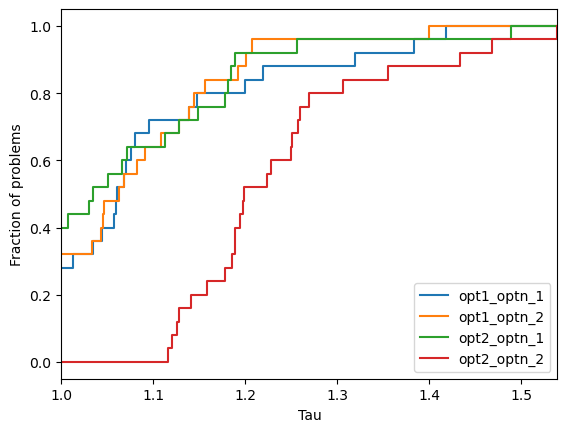

In [39]:
optperfprofpy.draw_simple_pp(taus, solver_vals, solvers)

Ok. Funziona. Adesso investighiamo cosa c'è

In [60]:
solvers

array(['opt1_optn_1', 'opt1_optn_2', 'opt2_optn_1', 'opt2_optn_2'],
      dtype=object)

In [63]:
display(taus)
print(f"type(taus) = {type(taus)},\ttaus.shape = {taus.shape}")

array([1.        , 1.00704225, 1.01257862, 1.03012048, 1.03305785,
       1.03401361, 1.03478261, 1.04255319, 1.04402516, 1.04516129,
       1.04678363, 1.05076142, 1.05714286, 1.05982906, 1.06043956,
       1.06293706, 1.0661157 , 1.06779661, 1.07042254, 1.07096774,
       1.07602339, 1.0802139 , 1.08176101, 1.09137056, 1.0955414 ,
       1.10884354, 1.11304348, 1.1161157 , 1.12042254, 1.12602339,
       1.12741935, 1.12790698, 1.12834225, 1.13829787, 1.13846154,
       1.14137056, 1.14457831, 1.14782609, 1.14835165, 1.15652174,
       1.15884354, 1.17834225, 1.17834395, 1.18095238, 1.18390805,
       1.18559322, 1.18829787, 1.18836478, 1.18881119, 1.19178082,
       1.19457831, 1.19782609, 1.19835165, 1.2       , 1.20125786,
       1.20689655, 1.21917808, 1.22391304, 1.22834395, 1.25      ,
       1.25125786, 1.25641026, 1.25689655, 1.25979021, 1.26917808,
       1.30641026, 1.31914894, 1.3547619 , 1.38372093, 1.4       ,
       1.41818182, 1.43372093, 1.46818182, 1.4893617 , 1.53936

type(taus) = <class 'numpy.ndarray'>,	taus.shape = (75,)


In [64]:
display(solver_vals)
print(f"type(solver_vals) = {type(solver_vals)},\t solver_vals.shape = {solver_vals.shape}")

array([[0.28, 0.28, 0.32, 0.32, 0.32, 0.32, 0.36, 0.36, 0.4 , 0.4 , 0.4 ,
        0.4 , 0.44, 0.48, 0.52, 0.52, 0.52, 0.56, 0.6 , 0.6 , 0.64, 0.68,
        0.68, 0.68, 0.72, 0.72, 0.72, 0.72, 0.72, 0.72, 0.72, 0.72, 0.72,
        0.76, 0.76, 0.76, 0.76, 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.8 ,
        0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.84, 0.84,
        0.84, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88,
        0.92, 0.92, 0.96, 0.96, 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.32, 0.32, 0.32, 0.32, 0.36, 0.36, 0.36, 0.4 , 0.4 , 0.44, 0.48,
        0.48, 0.48, 0.48, 0.48, 0.52, 0.52, 0.56, 0.56, 0.56, 0.56, 0.56,
        0.6 , 0.64, 0.64, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.72, 0.72,
        0.72, 0.76, 0.76, 0.8 , 0.8 , 0.8 , 0.84, 0.84, 0.84, 0.84, 0.84,
        0.84, 0.84, 0.84, 0.84, 0.84, 0.88, 0.88, 0.88, 0.88, 0.88, 0.92,
        0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96, 0.96,
        0.96, 0.96, 0.96, 1.  , 1.  , 1.  , 1.  ,

type(solver_vals) = <class 'numpy.ndarray'>,	 solver_vals.shape = (4, 75)


In [65]:
print("Note that:")
print(f"\tthere are {synthetic_df["feas"].sum()} feasible samples")
print(f"\tthere are {len(solvers)} solvers")

Note that:
	there are 75 feasible samples
	there are 4 solvers


I valori in `taus` e in `solver_vals` sono distinti? Dovrebbero!

In [66]:
taus_uniques = set(taus)
solver_vals_uniques = set().union(*[set(riga) for riga in solver_vals])

taus_uniques & solver_vals_uniques

{np.float64(1.0)}

In [ ]:
taus